In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# DATA LOADING AND INSPECTION

In [3]:
df = pd.read_csv('Titanic-Dataset.csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("DATA INFO")
information = df.info()

DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
missing= df.isnull().sum()

In [7]:
print("MISSING VALUES")
print(missing)

MISSING VALUES
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# DATA CLEANING

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median()) # filling null values in Age Col. with Median values

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) # filling null values in Embarked Col. with Mode values

df_cleaned = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1) # drop columns that won't help the model (general analysis)

In [9]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


# EDA AND VISUALISATION

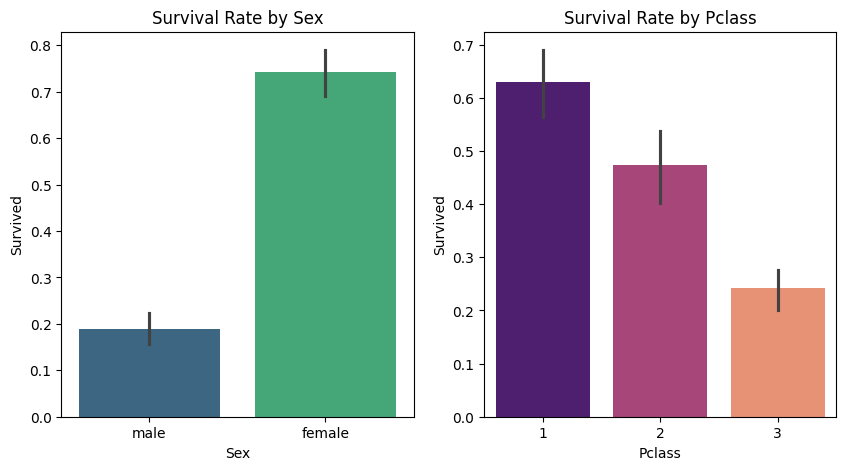

In [10]:
plt.figure(figsize=(10, 5))  # visualizing survival by Sex and Pclass

plt.subplot(1, 2, 1)
sns.barplot(x='Sex', y='Survived', data=df_cleaned, palette='viridis')
plt.title('Survival Rate by Sex')

plt.subplot(1, 2, 2)
sns.barplot(x='Pclass', y='Survived', data=df_cleaned, palette='magma')
plt.title('Survival Rate by Pclass')

plt.savefig('eda_results.png')
plt.show()

# Model Buidling and Testing on Dataset

Final Model Accuracy: 81.01%

Feature Importances:
Sex_male      0.398706
Fare          0.192164
Age           0.152397
Pclass        0.121778
SibSp         0.058461
Parch         0.038218
Embarked_S    0.026629
Embarked_Q    0.011645
dtype: float64


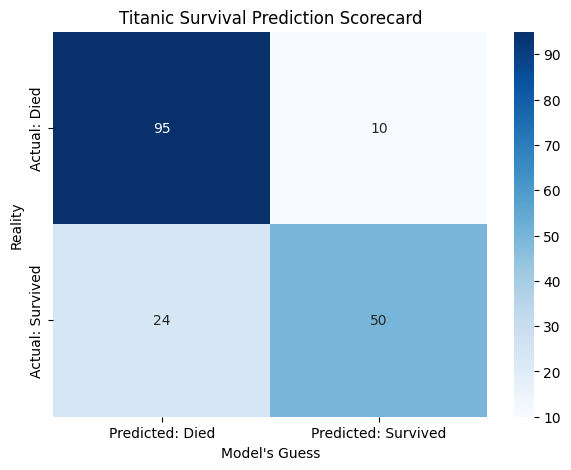

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('Titanic-Dataset.csv')

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df_cleaned = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

df_final = pd.get_dummies(df_cleaned, columns=['Sex', 'Embarked'], drop_first=True)


X = df_final.drop('Survived', axis=1) # spliting
y = df_final['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42) # model building using RANDOM FOREST METHOD
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test) # testing the model
acc = accuracy_score(y_test, y_pred)

print(f"Final Model Accuracy: {acc:.2%}")
print("\nFeature Importances:")
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

cm = confusion_matrix(y_test, y_pred) # using the Confusion matrix to visualize the results

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Died', 'Predicted: Survived'],
            yticklabels=['Actual: Died', 'Actual: Survived'])
plt.title('Titanic Survival Prediction Scorecard')
plt.ylabel('Reality')
plt.xlabel('Model\'s Guess')
plt.savefig('labeled_confusion_matrix.png')
plt.show()